## **Ex 5** - Extract patient’s insights using NLP model from a medical text.

_____

(Uses NLP techniques to process and extract meaningful information from a set of generated
medical texts)
______

## **Aim** : 
### To extract meaningful patient insights from medical text data using Natural Language Processing (NLP) techniques including text preprocessing, Named Entity Recognition (NER), sentiment analysis, and visualization.
_____

## **Procedure** : 
 

### Medical Text Analysis Workflow

1. **Set Up**: Initialize Jupyter notebook and create a new notebook.
2. **Import Libraries**: Import necessary libraries:
    * `pandas`, `numpy` (Data handling)
    * `re`, `nltk`, `spacy` (NLP & Cleaning)
    * `transformers` (Hugging Face models)
    * `wordcloud`, `matplotlib` (Visualization)
3. **Load Data**: Load medical text data.
4. **Preprocess Text Data**: Clean and tokenize the text data.
5. **Named Entity Recognition (NER)**: Use **spaCy** to perform NER on the medical text data.
6. **Sentiment Analysis**: Use the **transformers** library to perform sentiment analysis.
7. **Generate Word Cloud**: Create a word cloud to visualize the most common terms.
8. **Extract Insights**: Combine extracted entities and sentiment results to generate patient insights.


## Step 0 : Import the necessary Libraries

In [8]:
# # Install the spaCy library
# %pip install spacy

# # Download the English small model (en_core_web_sm)
# !python -m spacy download en_core_web_sm

# Install transformers and wordcloud
# %pip install transformers wordcloud

# # 1. Install PyTorch (The engine for the 'transformers' library)
# %pip install torch

# # 2. Download the missing spaCy English model
# !python -m spacy download en_core_web_sm




In [9]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
from transformers import pipeline
from nltk.corpus import  stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt 

# Download NLTK stopwords
nltk.download('stopwords')


# Load spaCy English model
nlp = spacy.load('en_core_web_sm')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


____
### 🛠️ NLP Pipeline: Tools and Libraries

#### **Library Requirements**
*   **pandas**: For data manipulation, cleaning, and creating DataFrames to store medical text.
*   **numpy**: For numerical operations and handling array-based data (supporting library).
*   **re (regex)**: For pattern-based text cleaning (removing special characters, numbers, and formatting).
*   **nltk**: Provides the **stopwords** list to remove common words (like "the", "is", "at") that don't add meaning.
*   **spaCy**: An advanced NLP library used here specifically for **Named Entity Recognition (NER)** to identify medical terms.
*   **transformers**: The Hugging Face library used to load pre-trained models for **Sentiment Analysis**.
*   **wordcloud**: Creates visual representations where the size of each word indicates its frequency.
*   **matplotlib**: The foundation for displaying all visualizations and plots.

#### **Inference**
These libraries form a complete **end-to-end NLP pipeline**, moving from raw text preprocessing and cleaning to advanced entity extraction, emotional analysis, and final visual insights.
____

## Step 1 : Load the Dataset (Medical Text)
 Create Sample Medical Text Dataset

In [10]:
# Sample Medical text dat representing patient records

medical_texts = [
    "Patient has a history of hypertension and diabetes. Prescribed medicationX.",
    "Asthma diagnosis confirmed. Patient advised to use inhaler daily.",
    "Hypertension patient. Needs regular monitoring of blood pressure.",
    "Diabetes patient. Recommended diet and exercise.",
    "Patient diagnosed with hypertension. Medication Y prescribed."   
]

#Create it into a DataFrame
medical_df = pd.DataFrame({'MedicalText': medical_texts})
print("Original Medical Texts:")
(medical_df.head())

Original Medical Texts:


,MedicalText
0,Patient has a history of hypertension and diab...
1,Asthma diagnosis confirmed. Patient advised to...
2,Hypertension patient. Needs regular monitoring...
3,Diabetes patient. Recommended diet and exercise.
4,Patient diagnosed with hypertension. Medicatio...


____
### 📊 Data Structuring & Tabulation

#### **Need:**
*   **Structured Format**: Creates a organized data structure required for systematic and automated processing.
*   **Granularity**: Ensures each row represents a unique patient record, clinical note, or observation for individual analysis.
*   **Efficiency**: The **DataFrame** format enables high-performance, column-wise operations (like cleaning or sentiment scoring) across the entire dataset simultaneously.

#### **Inference:**
Converting unstructured medical text into a **tabular format** is a critical first step. It allows for efficient batch processing and provides a clear audit trail of every transformation applied to each specific medical record.
____

## Step 2 : Preprocessing the Text 

In [11]:
def preprocess_text(text) :
    """ 
    Clean and standardize medical text for analysis
    
    Steps:
    1. Convert to lowercase
    2. Remove numbers
    3. Remove special characters/punctuation
    4. Remove stopwords
    
    """
    #convert to lower case
    text = text.lower()
    
    #Remove number
    text = re.sub( r'\d+', '', text)

    #remove special(non-word) characters (punctuation, symbols)
    text = re.sub(r'/W+',' ', text)
    
    #Remove stopwords 
    
    text = ' '.join([word for word in text.split()
                     if word not in stopwords.words('english')])   
    
    return text
    

In [12]:
medical_df.columns

Index(['MedicalText'], dtype='object')

In [29]:
# Apply preprocessing to all the ,medical texts

medical_df['CleanedText'] = medical_df['MedicalText'].apply(preprocess_text)

print("\n Precprocessed Text : ")
medical_df[['MedicalText', 'CleanedText']].head()


 Precprocessed Text : 


,MedicalText,CleanedText
0,Patient has a history of hypertension and diab...,patient history hypertension diabetes. prescri...
1,Asthma diagnosis confirmed. Patient advised to...,asthma diagnosis confirmed. patient advised us...
2,Hypertension patient. Needs regular monitoring...,hypertension patient. needs regular monitoring...
3,Diabetes patient. Recommended diet and exercise.,diabetes patient. recommended diet exercise.
4,Patient diagnosed with hypertension. Medicatio...,patient diagnosed hypertension. medication pre...


____
### 🧹 Text Preprocessing & Cleaning

#### **Need:**
*   **Lowercasing**: Ensures consistency across the dataset (e.g., treating "Diabetes" and "diabetes" as the same token).
*   **Remove Numbers**: Strips out numeric data that may be irrelevant for general linguistic or thematic analysis.
*   **Remove Special Characters**: Eliminates punctuation and symbols that do not contribute to core meaning extraction.
*   **Remove Stopwords**: Filters out high-frequency but low-meaning words (e.g., "the", "and", "is") to focus on significant medical terms.

#### **Inference:**
Preprocessing **standardizes the text** and drastically reduces noise. By retaining only meaningful words, we ensure higher accuracy for downstream tasks like entity recognition and sentiment analysis.
____

## Step 3 : Named Entity Recognition (NER) for Medical Entity Extraction

In [14]:
import spacy
from spacy.pipeline import EntityRuler
import pandas as pd

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Create EntityRuler and add patterns (Method 1: Add before adding to pipeline)
patterns = [
    {"label": "CONDITION", "pattern": [{"LOWER": "hypertension"}]},
    {"label": "CONDITION", "pattern": [{"LOWER": "diabetes"}]},
    {"label": "CONDITION", "pattern": [{"LOWER": "asthma"}]},
    {"label": "MEDICATION", "pattern": [{"LOWER": "medication"}, {"LOWER": "x"}]},
    {"label": "MEDICATION", "pattern": [{"LOWER": "medication"}, {"LOWER": "y"}]},
    {"label": "MEDICATION", "pattern": [{"LOWER": "inhaler"}]}
]

# Method 1: Add ruler with config
ruler = nlp.add_pipe("entity_ruler", before="ner")
ruler.add_patterns(patterns)

In [15]:
def extract_entities(text):
    """
    Extract named entities from medical text using spaCy
    
    Returns list of (entity_text, entity_type) tuples
    """
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

# Apply NER to original medical texts
medical_df['Entities'] = medical_df['MedicalText'].apply(extract_entities)

print("\nExtracted Entities:")
for idx, row in medical_df.iterrows():
    print(f"\nText {idx+1}: {row['MedicalText']}")
    print(f"Entities: {row['Entities']}")
    
medical_df.head()


Extracted Entities:

Text 1: Patient has a history of hypertension and diabetes. Prescribed medicationX.
Entities: [('hypertension', 'CONDITION'), ('diabetes', 'CONDITION')]

Text 2: Asthma diagnosis confirmed. Patient advised to use inhaler daily.
Entities: [('Asthma', 'CONDITION'), ('inhaler', 'MEDICATION'), ('daily', 'DATE')]

Text 3: Hypertension patient. Needs regular monitoring of blood pressure.
Entities: [('Hypertension', 'CONDITION')]

Text 4: Diabetes patient. Recommended diet and exercise.
Entities: [('Diabetes', 'CONDITION')]

Text 5: Patient diagnosed with hypertension. Medication Y prescribed.
Entities: [('hypertension', 'CONDITION'), ('Medication Y', 'MEDICATION')]


,MedicalText,CleanedText,Entities
0,Patient has a history of hypertension and diab...,patient history hypertension diabetes. prescri...,"[(hypertension, CONDITION), (diabetes, CONDITI..."
1,Asthma diagnosis confirmed. Patient advised to...,asthma diagnosis confirmed. patient advised us...,"[(Asthma, CONDITION), (inhaler, MEDICATION), (..."
2,Hypertension patient. Needs regular monitoring...,hypertension patient. needs regular monitoring...,"[(Hypertension, CONDITION)]"
3,Diabetes patient. Recommended diet and exercise.,diabetes patient. recommended diet exercise.,"[(Diabetes, CONDITION)]"
4,Patient diagnosed with hypertension. Medicatio...,patient diagnosed hypertension. medication pre...,"[(hypertension, CONDITION), (Medication Y, MED..."


____
### 🔍 Named Entity Recognition (NER)

#### **Need:**
*   **Condition Identification**: Automatically detects medical conditions such as **hypertension**, **diabetes**, or **asthma**.
*   **Medication Detection**: Isolates pharmaceutical mentions like **medication X**, **inhalers**, or **medication Y**.
*   **Treatment Extraction**: Recognizes specific treatment recommendations and clinical protocols.
*   **Structured Extraction**: Transforms unstructured clinical narratives into a structured data format for further analysis.

#### **Inference:**
NER serves as an automated "medical highlighter," identifying and classifying key information. This significantly reduces **manual review time** and enables the automated extraction of actionable insights from large volumes of patient notes.

____

## Step 4 : Sentiment Analysis

In [16]:
!pip install torch torchvision torchaudio

In [17]:
from transformers import pipeline
# Load the pre-trained sentiemt analysis pipeline
sentiement_pipeline = pipeline('sentiment-analysis')

def analyze_sentiment(text) :
    """ 
    Perform sentiment analysis on medical text
    
    Returns: Dictionary with 'label' and 'score'
    """
    result = sentiement_pipeline(text)[0]
    return result

# Apply sentiment Analysis
medical_df['Sentiment'] = medical_df['MedicalText'].apply(analyze_sentiment)

print("\nSentiment Analysis Results:")
for idx, row in medical_df.iterrows():
    sentiment = row['Sentiment']
    print(f"\nText {idx+1}: {row['MedicalText']}")
    print(f"Sentiment: {sentiment['label']} (Confidence: {sentiment['score']:.3f})")


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Sentiment Analysis Results:

Text 1: Patient has a history of hypertension and diabetes. Prescribed medicationX.
Sentiment: NEGATIVE (Confidence: 0.962)

Text 2: Asthma diagnosis confirmed. Patient advised to use inhaler daily.
Sentiment: NEGATIVE (Confidence: 0.965)

Text 3: Hypertension patient. Needs regular monitoring of blood pressure.
Sentiment: NEGATIVE (Confidence: 0.997)

Text 4: Diabetes patient. Recommended diet and exercise.
Sentiment: POSITIVE (Confidence: 0.971)

Text 5: Patient diagnosed with hypertension. Medication Y prescribed.
Sentiment: NEGATIVE (Confidence: 0.968)


____
### 🧠 Sentiment Analysis

#### **Need:**
*   **Tone Identification**: Detects the underlying emotional tone within medical records and clinical narratives.
*   **Psychological Insight**: Helps clinicians understand the patient’s psychological state and overall outlook on their health.
*   **Urgency Detection**: Flags high levels of concern or urgency in clinical notes that may require immediate follow-up.
*   **Context Enrichment**: Complements objective clinical data with subjective emotional context for a holistic patient view.

#### **Inference:**
Even clinical texts carry emotional undertones. Sentiment analysis reveals critical indicators of **patient well-being** and **treatment satisfaction**, highlighting areas that may need additional support beyond physical care.
_____

## Step 5 : Generate Word Cloud Visualization

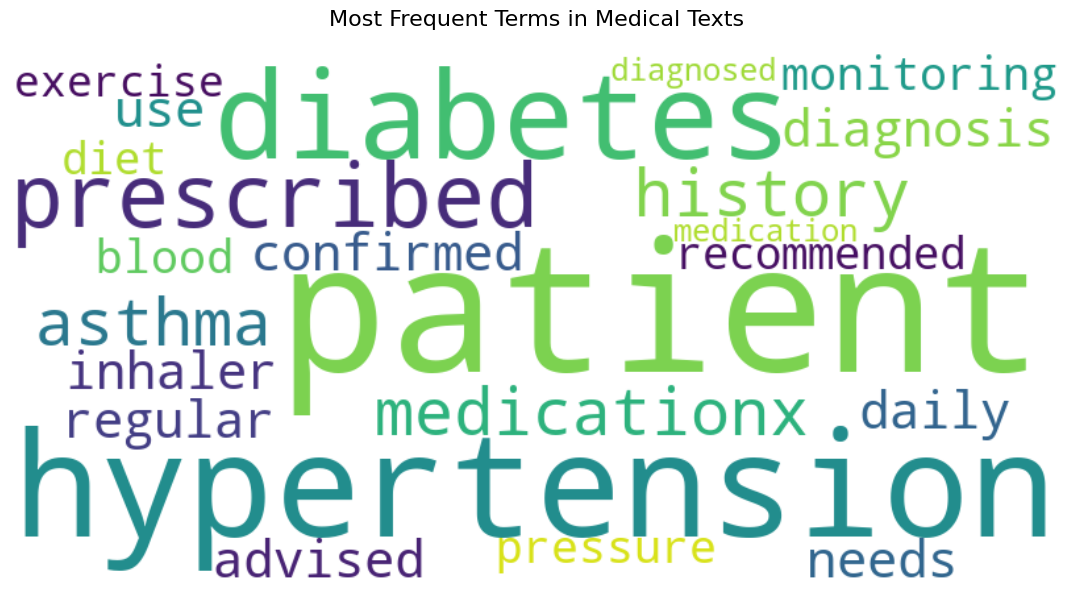

In [18]:
# Combine all the cleaned text for word cloud generation
all_text = ' '.join(medical_df['CleanedText'])

#Generate word cloud
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color='white',
    colormap='viridis'
).generate(all_text)

# Display wordcloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Terms in Medical Texts', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [19]:
# Display word frequency
from collections import Counter
words = all_text.split()
word_freq = Counter(words).most_common(10)
print("\nTop 10 Most Frequent Words:")
for word, count in word_freq:
    print(f"  {word}: {count}")


Top 10 Most Frequent Words:
  patient: 3
  hypertension: 2
  patient.: 2
  history: 1
  diabetes.: 1
  prescribed: 1
  medicationx.: 1
  asthma: 1
  diagnosis: 1
  confirmed.: 1


____
### ☁️ Word Cloud Visualization

#### **Need:**
*   **Term Importance**: Provides a visual representation where the size of the text indicates the frequency and importance of specific terms.
*   **Theme Identification**: Allows for the quick identification of dominant medical themes across the entire dataset.
*   **Highlight Focus**: Surfaces frequently mentioned conditions and treatments at a single glance.
*   **Dataset Validation**: Serves as a sanity check to ensure the data aligns with the intended medical domain.

#### **Inference:**
The word cloud serves as a visual confirmation of our focus; it should prominently feature terms like **hypertension**, **diabetes**, and **asthma**, validating that the preprocessing and data loading were successful.

____

## Step 6 : Extract Comprehensive Patient Insights

In [21]:
# Extract Insights

def extract_insights(row) :
    entities = row['Entities']
    sentiment = row['Sentiment']
    
    return {
        'Entities' : entities,
        'Sentiment' : sentiment['label'],
        'SentimentScore' : sentiment['score']
    }
    
medical_df['Insights'] = medical_df.apply(extract_insights,axis=1)
medical_df[['MedicalText', 'Insights']].head() 

,MedicalText,Insights
0,Patient has a history of hypertension and diab...,"{'Entities': [('hypertension', 'CONDITION'), (..."
1,Asthma diagnosis confirmed. Patient advised to...,"{'Entities': [('Asthma', 'CONDITION'), ('inhal..."
2,Hypertension patient. Needs regular monitoring...,"{'Entities': [('Hypertension', 'CONDITION')], ..."
3,Diabetes patient. Recommended diet and exercise.,"{'Entities': [('Diabetes', 'CONDITION')], 'Sen..."
4,Patient diagnosed with hypertension. Medicatio...,"{'Entities': [('hypertension', 'CONDITION'), (..."


In [27]:
def extract_insights(row):
    """
    Combine entities and sentiment into comprehensive insights
    """
    entities = row['Entities']
    sentiment = row['Sentiment']
    
    # Categorize entities by type
    medical_conditions = []
    medications = []
    others = []
    
    for entity_text, entity_type in entities:
        if entity_type in ['DISEASE', 'CONDITION']:
            medical_conditions.append(entity_text)
        elif entity_type in ['MEDICATION', 'DRUG']:
            medications.append(entity_text)
        else:
            others.append((entity_text, entity_type))
    
    return {
        'medical_conditions': medical_conditions,
        'medications': medications,
        'other_entities': others,
        'sentiment_label': sentiment['label'],
        'sentiment_confidence': round(sentiment['score'], 3)
    }

# Apply insight extraction
medical_df['Insights'] = medical_df.apply(extract_insights, axis=1)

print("\n" + "="*80)
print("FINAL PATIENT INSIGHTS")
print("="*80)

for idx, row in medical_df.iterrows():
    print(f"\n--- PATIENT RECORD {idx+1} ---")
    print(f"Original Text: {row['MedicalText']}")
    
    insights = row['Insights']
    print(f"\n📋 Medical Conditions: {insights['medical_conditions']}")
    print(f"💊 Medications: {insights['medications']}")
    print(f"📌 Other Entities: {insights['other_entities']}")
    print(f"😊 Sentiment: {insights['sentiment_label']} "
          f"(Confidence: {insights['sentiment_confidence']})")


FINAL PATIENT INSIGHTS

--- PATIENT RECORD 1 ---
Original Text: Patient has a history of hypertension and diabetes. Prescribed medicationX.

📋 Medical Conditions: ['hypertension', 'diabetes']
💊 Medications: []
📌 Other Entities: []
😊 Sentiment: NEGATIVE (Confidence: 0.962)

--- PATIENT RECORD 2 ---
Original Text: Asthma diagnosis confirmed. Patient advised to use inhaler daily.

📋 Medical Conditions: ['Asthma']
💊 Medications: ['inhaler']
📌 Other Entities: [('daily', 'DATE')]
😊 Sentiment: NEGATIVE (Confidence: 0.965)

--- PATIENT RECORD 3 ---
Original Text: Hypertension patient. Needs regular monitoring of blood pressure.

📋 Medical Conditions: ['Hypertension']
💊 Medications: []
📌 Other Entities: []
😊 Sentiment: NEGATIVE (Confidence: 0.997)

--- PATIENT RECORD 4 ---
Original Text: Diabetes patient. Recommended diet and exercise.

📋 Medical Conditions: ['Diabetes']
💊 Medications: []
📌 Other Entities: []
😊 Sentiment: POSITIVE (Confidence: 0.971)

--- PATIENT RECORD 5 ---
Original Text: Pa

In [28]:
# Aggregate insights across all patients
all_conditions = []
all_medications = []
sentiment_counts = {'POSITIVE': 0, 'NEGATIVE': 0}

for insights in medical_df['Insights']:
    all_conditions.extend(insights['medical_conditions'])
    all_medications.extend(insights['medications'])
    sentiment_counts[insights['sentiment_label']] += 1

print("\n" + "="*80)
print("AGGREGATED SUMMARY ACROSS ALL PATIENTS")
print("="*80)

print(f"\n📊 Total Patients Analyzed: {len(medical_df)}")
print(f"\n🏥 Medical Conditions Found:")
condition_freq = Counter(all_conditions).most_common()
for condition, count in condition_freq:
    print(f"   • {condition}: {count} patient(s)")

print(f"\n💊 Medications Prescribed:")
med_freq = Counter(all_medications).most_common()
for med, count in med_freq:
    print(f"   • {med}: {count} patient(s)")

print(f"\n😊 Sentiment Distribution:")
print(f"   • Positive: {sentiment_counts['POSITIVE']} patients")
print(f"   • Negative: {sentiment_counts['NEGATIVE']} patients")


AGGREGATED SUMMARY ACROSS ALL PATIENTS

📊 Total Patients Analyzed: 5

🏥 Medical Conditions Found:
   • hypertension: 2 patient(s)
   • diabetes: 1 patient(s)
   • Asthma: 1 patient(s)
   • Hypertension: 1 patient(s)
   • Diabetes: 1 patient(s)

💊 Medications Prescribed:
   • inhaler: 1 patient(s)
   • Medication Y: 1 patient(s)

😊 Sentiment Distribution:
   • Positive: 1 patients
   • Negative: 4 patients
